In [1]:
conda activate omfitenv


Note: you may need to restart the kernel to use updated packages.


In [2]:
from omfit_classes import omfit_eqdsk

In [3]:
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from uncertainties import ufloat
import numpy as np
from scipy.integrate import cumtrapz
from scipy.constants import mu_0
import os

10.823088353317303
2260.600576453191


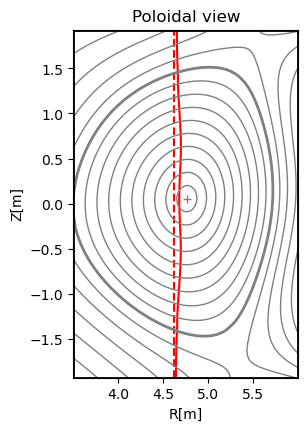

In [30]:
# FILES
#Change this
for sim_index in [0]:

    cwd = os.getcwd()
    SCAN_dir = cwd+'/SCAN'
    work_dir = SCAN_dir+'/work'
    
    fastran_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_tr_')]
    ffile = work_dir+'/'+fastran_dir[0]+'/fastran.nc'
    gfile = work_dir+'/'+fastran_dir[0]+'/g000001.00001'
    
    
    # ORIGINAL TORAY PLOTTING SCRIPT
    #Python
    # originally by Orso
    # modified by Zhixuan 1/7/2015
    import scipy.constants as sc
    
    rootgrp = Dataset(ffile)
    geqdsk = omfit_eqdsk.OMFITgeqdsk(gfile)
    
    n_e = rootgrp['ne'][-1,:]
    n_i = rootgrp['ni'][-1,:]
    frac_He3 = 0.02
    
    phi_exp = 0
    alpha = 0.1

    # poloidal cross-section
    plt.subplot(1, 2, 2)  # ,aspect='equal')
    
    Zmax = max(geqdsk['ZLIM'])
    Zmin = min(geqdsk['ZLIM'])
    
    # calculate the resonance field
    m_e = sc.m_e
    m_p = sc.m_p
    q_e = sc.elementary_charge
    eps_0 = sc.epsilon_0
    freq = 110e6 #the input to TORIC simulations from MANTA
    #B_res = freq*2*np.pi*m_e/q_e
    Z_ion = 2
    m_ion_multiplier = 3
    B_res = freq*2*np.pi*m_ion_multiplier*m_p/(Z_ion*q_e) #minority resonance (He3)

    Z_ion = 1
    m_ion_multiplier = 1
    # calculate cutoff field
    N_e = n_e*10**19 #number density of electrons
    #N_He3 = frac_He3*n_e*10**19 #number density of He3
    N_D = n_i*10**19
    #w_pe_squared = N_e*q_e**2/(eps_0*m_e)
    w_pe_squared = N_D*(Z_ion*q_e)**2/(eps_0*m_ion_multiplier*m_p)
    
    B_cutoff_1 = (m_ion_multiplier*m_p/(Z_ion*q_e))*(w_pe_squared-(2*np.pi*freq)**2)/(2*np.pi*freq)
    B_cutoff_2 = (m_ion_multiplier*m_p/(Z_ion*q_e))*(w_pe_squared-(2*np.pi*freq)**2)/(-2*np.pi*freq)
    
    # accurate resonant surface
    R, Z = np.meshgrid(geqdsk['AuxQuantities']['R'], geqdsk['AuxQuantities']['Z'])
    B = np.sqrt(geqdsk['AuxQuantities']['Bt'] ** 2 + geqdsk['AuxQuantities']['Br'] ** 2 + geqdsk['AuxQuantities']['Bz'] ** 2)
    plt.contour(R, Z, B, [B_res],colors ='r') #POLODIAL RESONANT SURFACE
    print(B_res)
    
    # accurate cutoff surface
    plt.contour(R, Z ,B, [B_cutoff_1[-1]], colors = 'b')
    plt.contour(R, Z ,B, [B_cutoff_1[0]], colors = 'b')
    print(B_cutoff_1[-1])
    
    # approximate resonant surface, as the one shown in the toroidal view
    t_angle = np.arange(0, 2 * np.pi, 0.02 * np.pi)
    t_angle = np.append(t_angle, 2 * np.pi)
    R_res = abs(geqdsk['RCENTR'] * geqdsk['BCENTR'] / B_res)
    X_res = R_res * np.cos(t_angle)
    Y_res = R_res * np.sin(t_angle)
    plt.plot([R_res, R_res], [Zmin, Zmax], 'r--') #POLODIAL APPROXIMATE RESONANT SURFACE?
    

geqdsk.plot(only2D=True, color='grey') #POLOIDAL CROSS SECTION
plt.xlabel('R[m]')
plt.ylabel('Z[m]')

plt.title('Poloidal view')
plt.show()

In [28]:
# FFILE DATA
rootgrp = Dataset(ffile)

rho = rootgrp['rho'][:]

te = rootgrp['te'][-1,:]
ti = rootgrp['ti'][-1,:]

prfe = rootgrp['pe_rf'][-1,:]
prfe_int = rootgrp['prfe'][-1]
prfi = rootgrp['pi_rf'][-1,:]
prfi_int = rootgrp['prfi'][-1]

jbs = rootgrp['j_bs'][-1,:]
ibs = rootgrp['ibs'][-1]
jrf = rootgrp['j_rf'][-1,:]
irf = rootgrp['irf'][-1]
jtot = rootgrp['j_tot'][-1,:]




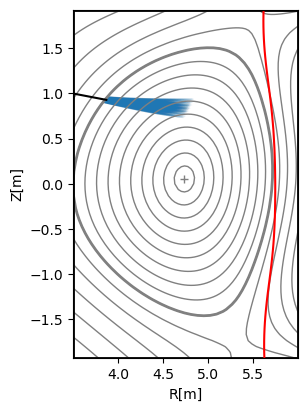

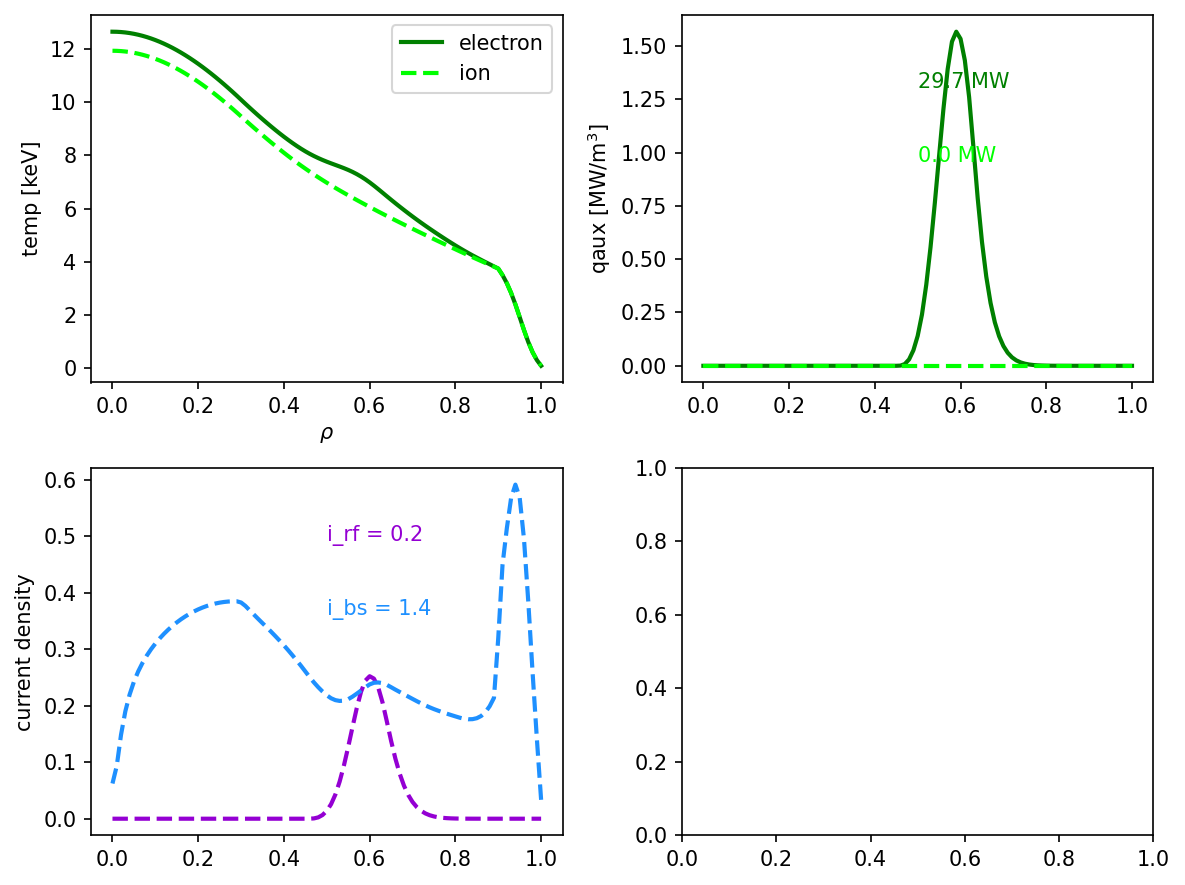

In [69]:
#PLOTS

# Plot poloidal cross section
plt.subplot(1, 2, 2, aspect='equal')
geqdsk.plot(only2D=True, color='grey') #POLOIDAL CROSS SECTION
plt.contour(R, Z, B, [B_res], colors='r') #POLODIAL RESONANT SURFACE
plt.scatter(wr, wz, s, alpha=alpha)#, cmap='rainbow') ## POLOIDAL RAYS ##this used plotc, which colors the scatter points with a colorbar

plt.plot([R0t, wr[0, 0]], [z0, z1], 'k') ##POLOIDAL ANTENNA
plt.xlabel('R[m]')
plt.ylabel('Z[m]')
plt.show()

fig, ((ax1,ax2),(ax3,ax4)) =plt.subplots(2,2,figsize =(8,6),dpi = 150)
lw = 2
c1 = 'green'
c2 = 'lime'
c3 = 'magenta'
c4 = 'darkviolet'
c5 = 'dodgerblue'
c6 = 'cyan'

# Plot temperature
ax1.plot(rho,te,color = c1,linewidth = lw, label = 'electron')
ax1.plot(rho,ti,color = c2,linewidth = lw,linestyle = 'dashed', label = 'ion')
ax1.set_ylabel('temp [keV]')
ax1.set_xlabel('$\\rho$')
ax1.legend()

# Plot heating
ax2.plot(rho,prfe,color = c1,linewidth = lw)
ax2.plot(rho,prfi,color = c2,linewidth = lw,linestyle = 'dashed')
ax2.set_ylabel('qaux [MW/m$^3$]')
ax2.text(0.5,0.8,'{:.1f} MW'.format(prfe_int),color = c1, transform = ax2.transAxes)
ax2.text(0.5,0.6,'{:.1f} MW'.format(prfi_int),color = c2, transform = ax2.transAxes)

# Plot current
ax3.plot(rho,jrf,color = c4,linewidth = lw,linestyle = 'dashed')
ax3.plot(rho,jbs,color = c5, linewidth =lw, linestyle='dashed')
ax3.text(0.5,0.8,'i_rf = {:.1f}'.format(irf),color = c4,transform = ax3.transAxes)
ax3.text(0.5,0.6,'i_bs = {:.1f}'.format(ibs),color = c5,transform = ax3.transAxes)
ax3.set_ylabel('current density')

fig.tight_layout()
plt.show()

27992489872.33304
